# GAT Spatial Cross-Validated Accessibility Model

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np

import torch
import torch.nn.functional as F

from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

from torch_geometric.data import Data
from torch_geometric.nn import GATConv

In [2]:
# CONFIG
STATE = "13"
COUNTIES = ["121", "089", "067", "135"]

N_CLUSTERS = 5
RANDOM_STATE = 42
TARGET_VARIABLE = "access_index"

In [3]:
X_df = pd.read_parquet("../data/processed_predictors/atlanta_2023_predictor_dataset.parquet")
y_df = pd.read_parquet("../data/processed_job_accessibility/accessibility_state-GA_counties-121-089-067-135_year-2023_thresholds-15-30-45-60.parquet")

print(X_df.shape, y_df.shape)

(936, 44) (936, 5)


In [4]:
target_cols = ["jobs_15min", "jobs_30min", "jobs_45min", "jobs_60min"]

weights = np.array([1.0, 0.7, 0.4, 0.2])

y_multi = np.log1p(y_df[target_cols])
y_df["access_index"] = (y_multi * weights).sum(axis=1)

In [5]:
df = X_df.merge(
    y_df[["from_id"] + target_cols + ["access_index"]],
    left_on="tract_id",
    right_on="from_id",
    how="inner"
)

url = (
    f"https://www2.census.gov/geo/tiger/TIGER2023/"
    f"TRACT/tl_2023_{STATE}_tract.zip"
)

tracts = gpd.read_file(url)
tracts = tracts[tracts["COUNTYFP"].isin(COUNTIES)].copy()
tracts["tract_id"] = tracts["GEOID"].astype(str)

df = df.merge(tracts[["tract_id", "geometry"]], on="tract_id", how="left")

gdf = gpd.GeoDataFrame(df, geometry="geometry", crs=tracts.crs).to_crs(5070)

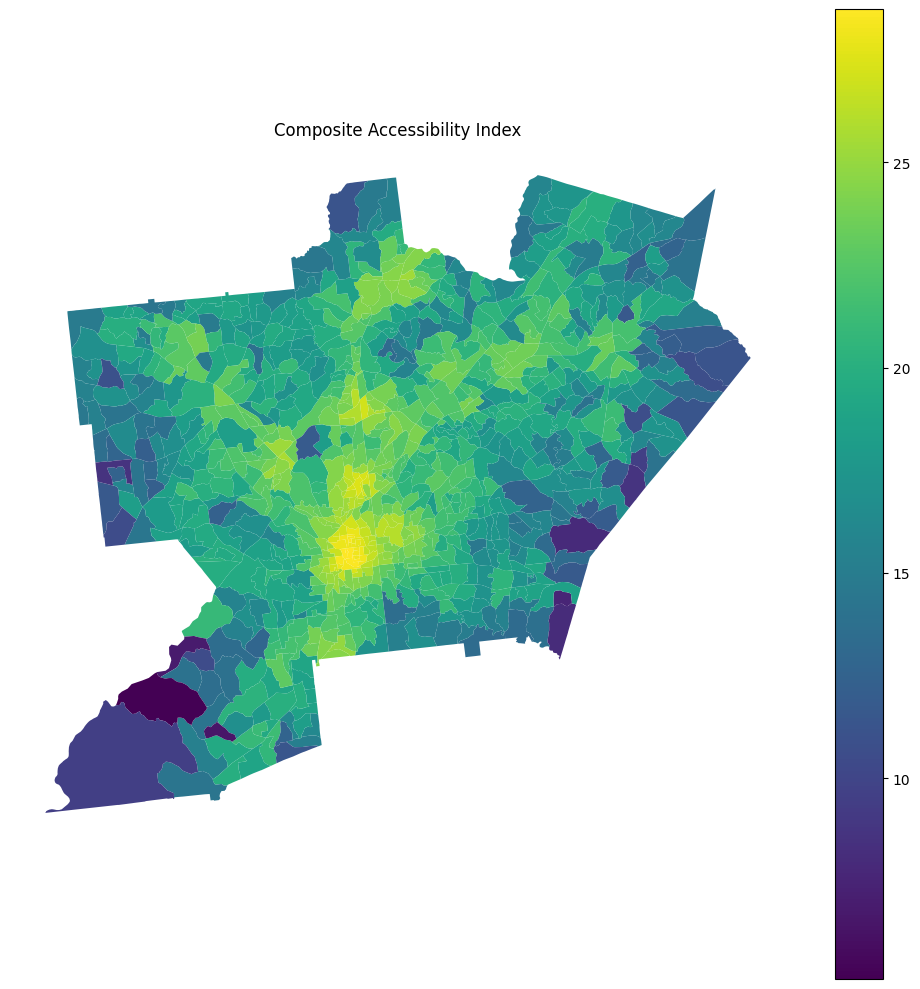

In [6]:
fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    column="access_index",
    cmap="viridis",
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey"}
)

ax.set_title("Composite Accessibility Index")
ax.axis("off")

plt.tight_layout()
plt.show()

In [7]:
gdf["centroid"] = gdf.geometry.centroid
gdf["x"] = gdf.centroid.x
gdf["y"] = gdf.centroid.y

coords = np.column_stack([gdf["x"], gdf["y"]])

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init="auto")
gdf["cluster"] = kmeans.fit_predict(coords)

In [8]:
def build_edges(gdf):
    gdf = gdf.reset_index(drop=True)
    sindex = gdf.sindex

    edges = []

    for i, geom in enumerate(gdf.geometry):
        possible = list(sindex.intersection(geom.bounds))
        candidates = gdf.iloc[possible]

        # adjacency approximation
        neighbors = candidates[candidates.geometry.intersects(geom)]

        for j in neighbors.index:
            if i != j:
                edges.append((i, j))

    return edges

edges = build_edges(gdf)

edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

In [9]:
exclude = [
    "tract_id", "from_id", "geometry",
    "centroid", "x", "y", "cluster",
    "access_index"
] + target_cols

feature_cols = [c for c in gdf.columns if c not in exclude]

X = gdf[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X = torch.tensor(X, dtype=torch.float)

y = torch.tensor(np.log1p(gdf["access_index"].values), dtype=torch.float)

In [10]:
data = Data(x=X, edge_index=edge_index, y=y)

In [11]:
class GATModel(torch.nn.Module):
    def __init__(self, in_channels):
        super().__init__()

        self.mlp = torch.nn.Sequential(
            torch.nn.Linear(in_channels, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 64),
            torch.nn.ReLU()
        )

        self.gat1 = GATConv(64, 32, heads=4, dropout=0.2)
        self.gat2 = GATConv(128, 32, heads=2, dropout=0.2)

        self.out = torch.nn.Linear(64, 1)

    def forward(self, x, edge_index):
        x = self.mlp(x)

        x = self.gat1(x, edge_index)
        x = F.elu(x)

        x = self.gat2(x, edge_index)
        x = F.elu(x)

        return self.out(x).squeeze()

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GATModel(data.x.shape[1]).to(device)
data = data.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)
loss_fn = torch.nn.MSELoss()

In [13]:
num_nodes = gdf.shape[0]

train_masks = []
test_masks = []

split_gdf = gdf.copy()

for c in range(N_CLUSTERS):

    train_idx = split_gdf.index[split_gdf["cluster"] != c].to_numpy()
    test_idx = split_gdf.index[split_gdf["cluster"] == c].to_numpy()

    train_mask = torch.zeros(num_nodes, dtype=torch.bool)
    test_mask = torch.zeros(num_nodes, dtype=torch.bool)

    train_mask[train_idx] = True
    test_mask[test_idx] = True

    train_masks.append(train_mask.to(device))
    test_masks.append(test_mask.to(device))

/tmp/ipykernel_69151/591024842.py:16: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  train_mask[train_idx] = True


In [14]:
results = []
all_preds = []

for fold in range(N_CLUSTERS):

    print("\nFold:", fold)

    train_mask = train_masks[fold]
    test_mask = test_masks[fold]

    for epoch in range(1, 151):

        model.train()
        optimizer.zero_grad()

        out = model(data.x, data.edge_index)

        loss = loss_fn(out[train_mask], data.y[train_mask])
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        pred = model(data.x, data.edge_index)

    pred_np = np.expm1(pred.cpu().numpy())
    true_np = np.expm1(data.y.cpu().numpy())

    y_pred = pred_np[test_mask.cpu()]
    y_true = true_np[test_mask.cpu()]

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print("RMSE:", rmse, "R2:", r2)

    results.append({
        "fold": fold,
        "rmse": rmse,
        "r2": r2
    })

    all_preds.append(pd.DataFrame({
        "tract_id": gdf.loc[gdf.index[test_mask.cpu().numpy()], "tract_id"].values,
        "fold": fold,
        "actual": y_true,
        "predicted": y_pred
    }))


Fold: 0
RMSE: 2.3280960183611903 R2: 0.4116341471672058

Fold: 1
RMSE: 2.9534119158839416 R2: 0.5686507821083069

Fold: 2
RMSE: 2.3183927975489413 R2: 0.5578931570053101

Fold: 3
RMSE: 2.3186178987202943 R2: 0.5322902202606201

Fold: 4
RMSE: 2.1464748226158012 R2: 0.5631230473518372


In [15]:
results_df = pd.DataFrame(results)
print(results_df.mean())

fold    2.000000
rmse    2.412999
r2      0.526718
dtype: float64


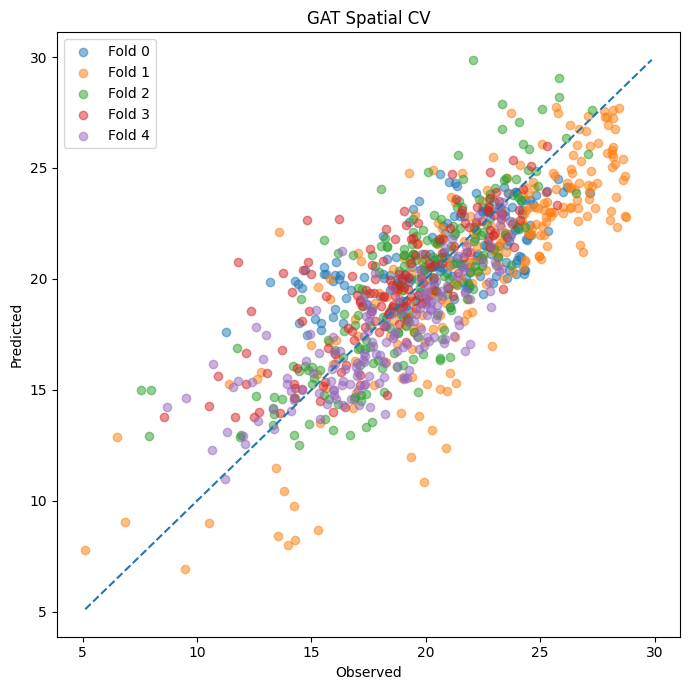

In [16]:
pred_df = pd.concat(all_preds, ignore_index=True)

fig, ax = plt.subplots(figsize=(7, 7))

for f in pred_df["fold"].unique():
    d = pred_df[pred_df["fold"] == f]
    ax.scatter(d["actual"], d["predicted"], alpha=0.5, label=f"Fold {f}")

min_v = min(pred_df["actual"].min(), pred_df["predicted"].min())
max_v = max(pred_df["actual"].max(), pred_df["predicted"].max())

ax.plot([min_v, max_v], [min_v, max_v], "--")

ax.legend()
ax.set_title("GAT Spatial CV")
ax.set_xlabel("Observed")
ax.set_ylabel("Predicted")

plt.tight_layout()
plt.show()

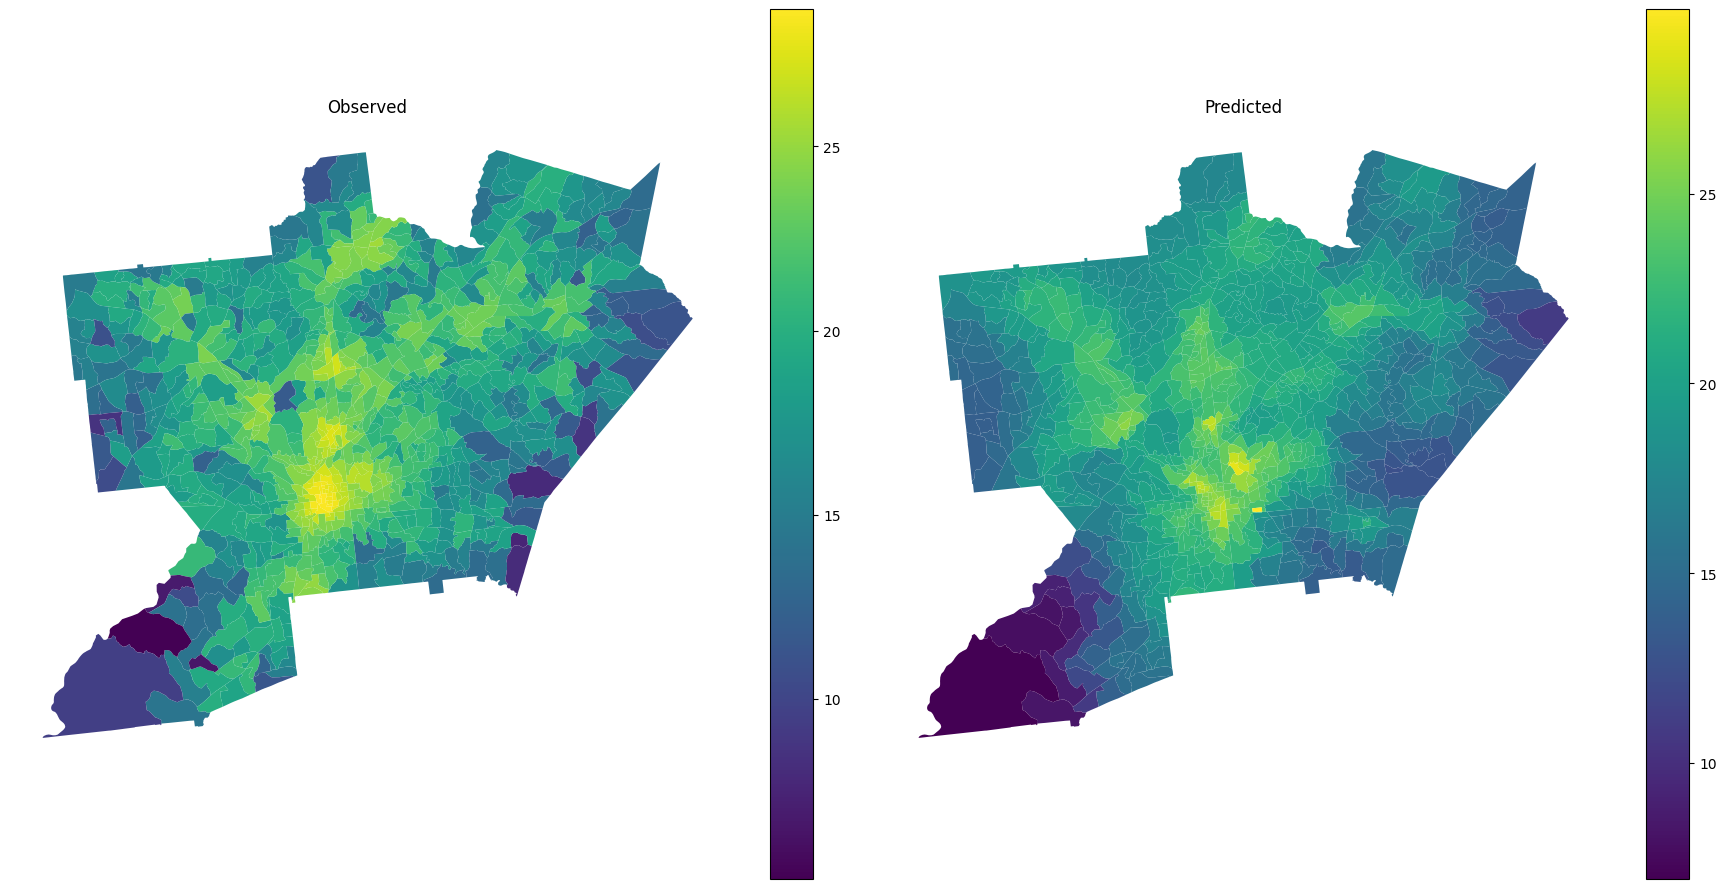

In [17]:
map_df = gdf[["tract_id", "geometry"]].merge(
    pred_df.groupby("tract_id")[["predicted", "actual"]].mean().reset_index(),
    on="tract_id",
    how="left"
)

map_gdf = gpd.GeoDataFrame(map_df, geometry="geometry", crs=gdf.crs)

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

map_gdf.plot(column="actual", cmap="viridis", ax=axes[0], legend=True)
axes[0].set_title("Observed")

map_gdf.plot(column="predicted", cmap="viridis", ax=axes[1], legend=True)
axes[1].set_title("Predicted")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()